In [128]:
#impots


## **Generating graph and then calculating the epi threshold**


generate graph statistcs based on gravity theory

In [129]:
def radiation_model(number_nodes, positions, population):

    rows,cols, weights = [], [], []

    for i in range(number_nodes):
        distance = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distance[i] = np.inf
        distance[distance == 0] = 0.1


        #radiation model simini paper
        #flow ij = mi * ( minj/ (mi + sij) * (mi + nj + sij))
        #sij = sum of populations in distance between city i and j minus original

        for j in range(number_nodes):
            if j == i:
                 flow = np.random.uniform(0.25, 0.40) * population[i] #selfflows
            else:
                r_ij = distance[j]
                # print(r_ij)
                # if r_ij > 5000: # distance cutoff
                #     flow = 0
                #     continue
                # else:
                s_ij = population[(distance < r_ij)].sum() - population[i] - population[j]
                s_ij = max(0,  s_ij) #no negative s

                first_term = population[i] * population[j]
                second_term = (population[i] + s_ij) * (population[i] + population[j] + s_ij)
                if second_term > 0:
                    flow = population[i] * first_term / second_term

            rows.append(i)
            cols.append(j)
            weights.append(flow)
        #print(flow)




    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    weights = weights / row_sums[rows]

    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)





In [130]:
from scipy.sparse import coo_matrix
import numpy as np

def generate_graph(total_population, number_nodes, area):

   #zipfs law fore reaslitc cities
    rank = np.arange(1, number_nodes + 1)
    population_distribution = 1 / rank
    population = (population_distribution / population_distribution.sum()) * total_population
    population[0] += total_population - population.sum() #for integer rounding errors

    side_length = np.sqrt(area)
    positions = np.random.rand(number_nodes, 2) * side_length

    # side = np.sqrt(area)
    # cluster_centres = np.random.rand(number_nodes, 2) * side
    # positions = np.array([
    #     np.clip(cluster_centres[i % number_nodes] + np.random.randn(2) * side * 0.08, 0, side)
    #     for i in range(number_nodes)])

    rows, cols, weights = radiation_model(number_nodes, positions, population)

    #create graph
    graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
    graph = graph.tocsr()

    return graph, population, positions


visualse graph

In [131]:
import networkx as nx
import matplotlib.pyplot as plt

def visualise_graph(graph):
    graph = nx.from_scipy_sparse_array(graph)

    # threshold = 0.5  # Example threshold
    # elarge = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] > threshold]

    # 3. Draw
    pos = nx.spring_layout(graph, seed=42)  # Positions for all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=10)
    nx.draw_networkx_edges(graph, pos, width=0.1, alpha=0.5)

    plt.title("Flow Graph (Filtered)")
    plt.show()



calculate matrix M

In [132]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3



call functions and calculate spectral radius --> epidemic threshold

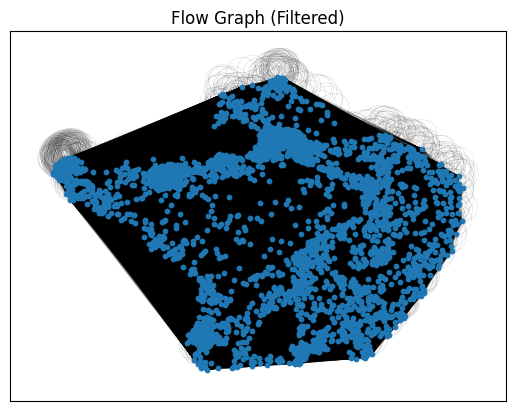

1.2958463758411365
0.7716964129724853


In [140]:
from scipy.linalg import eig

def generate_data(total_population,total_area,number_nodes, recovery_rate, mobility_rate = 1 ):
    graph,population,positions = generate_graph(total_population, number_nodes, total_area)
    visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist
    log_population = np.log1p(population)
    area_distr = (log_population/np.sum(log_population)) * total_area


    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)
    # print(recovery_rate / spectral_radius_2)

    # print(spectral_radius / spectral_radius_2)

    # print(eff_population)
    # print(area_distr)
    # print()

#generate_data(5600000, 4774, 350, 1, 1)
generate_data(312969665, 3574052, 3220, 1, 1)


## **Give epdemic treshhold and then make graph based off of thath**

In [134]:
import torch

def calculte_m_torch(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - torch.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1
    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = torch.diag(m1) #kronegers thing makes it a diagonal

    graph_scaled = graph * f_neff[None, :]

    m2 = mobility_rate * (1-mobility_rate) * (graph_scaled + graph_scaled.T)
    m3= (mobility_rate**2) * (graph_scaled @ graph.T)

    return m1 + m2 + m3

In [135]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualise_optimised_graph(original_R, optimised_R, population, positions):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0d0d0d')

    for ax, R, title in zip(axes, [original_R, optimised_R], ['Original Graph', 'Optimised Graph']):
        ax.set_facecolor('#0d0d0d')

        G = nx.DiGraph()
        n = R.shape[0]

        for i in range(n):
            G.add_node(i, population=population[i])

        # only add strong edges to avoid clutter
        threshold = np.percentile(R, 90)
        for i in range(n):
            for j in range(n):
                if R[i,j] > threshold:
                    G.add_edge(i, j, weight=R[i,j])

        pos = {i: positions[i] for i in range(n)}

        # node size by population
        node_sizes = (population / population.max()) * 1000 + 50

        # node color by population
        node_colors = population / population.max()

        # edge width by weight
        edges = G.edges(data=True)
        weights = [e[2]['weight'] for e in edges]

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3,
                               width=[w * 10 for w in weights],
                               edge_color=weights, edge_cmap=cm.plasma,
                               arrows=True, arrowsize=10)

        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=cm.plasma, alpha=0.9)

        ax.set_title(title, color='white', fontsize=16, pad=20,
                     fontfamily='monospace')
        ax.axis('off')

    plt.suptitle('Graph Optimisation — Epidemic Threshold',
                 color='white', fontsize=20, fontfamily='monospace', y=1.02)
    plt.tight_layout()
    plt.savefig('optimised_graph.png', dpi=150, bbox_inches='tight',
                facecolor='#0d0d0d')
    plt.show()

# usage


In [136]:
def gravity_flows_torch(population_norm, positions):
    diff = positions[:, None, :] - positions[None, :, :]  # (N,N,2)
    distances = torch.sqrt((diff**2).sum(dim=-1))
    distances = distances + torch.eye(len(population_norm)) * 1e10  # mask diagonal

    flow = (population_norm[:, None] * population_norm[None, :]) / (distances**2)
    flow = flow * (1 - torch.eye(len(population_norm)))

    # normalise rows
    row_sums = flow.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return flow / row_sums

hello1
hello2
hello
step 0, spectral_radius: 0.9042, loss: 5.900931
step 100, spectral_radius: 2.5346, loss: 0.637920
step 200, spectral_radius: 3.3200, loss: 0.000177
step 300, spectral_radius: 3.3375, loss: 0.000017
step 400, spectral_radius: 3.3333, loss: 0.000000
step 500, spectral_radius: 3.3333, loss: 0.000000
step 600, spectral_radius: 3.3333, loss: 0.000000
step 700, spectral_radius: 3.3333, loss: 0.000000
step 800, spectral_radius: 3.3333, loss: 0.000000
step 900, spectral_radius: 3.3333, loss: 0.000000


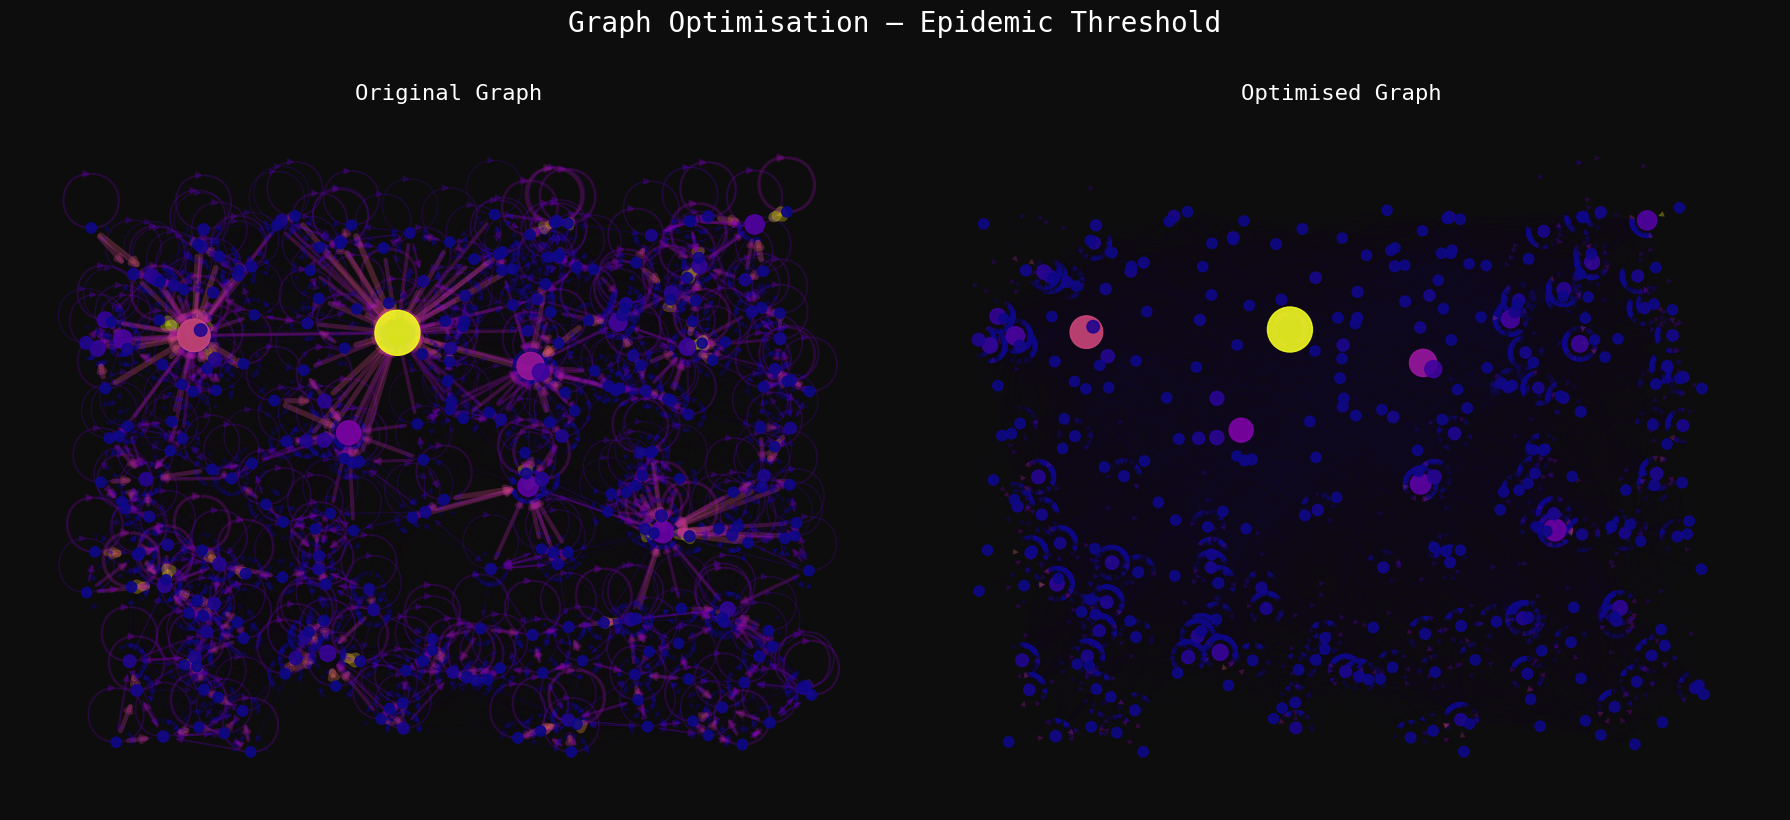

In [137]:
from torch.linalg import eigvals

def method2(epedmic_treshold, total_population,total_area,number_nodes, recovery_rate, mobility_rate = 1, lr=0.01, steps=1000, max_loss = 0.001):

    target_spectral_radius = recovery_rate/epedmic_treshold
    print("hello1")
    starting_graph, starting_population, positions = generate_graph(total_population, number_nodes, total_area)


    print("hello2")

      #devide area acording to log-linear dist
    log_population = np.log1p(starting_population)
    area_distr = (log_population/np.sum(log_population)) * total_area

    positions= torch.tensor(positions, dtype=torch.float32)
    graph = torch.tensor(starting_graph.toarray(), dtype=torch.float32, requires_grad=True)
    population = torch.tensor(starting_population, dtype=torch.float32, requires_grad = True)
    area_distr = torch.tensor(area_distr, dtype=torch.float32)

    optimizer = torch.optim.Adam([graph, population], lr=0.01, betas=(0.95, 0.999))

    print("hello")
    alpha = 0.5



    for step in range(steps):
        optimizer.zero_grad()


        population_norm = torch.softmax(population, dim=0) * total_population

        graph_from_pop = gravity_flows_torch(population_norm, positions)
        graph_norm = (1 - alpha) * torch.softmax(graph, dim=1) + alpha * graph_from_pop

        log_pop = torch.log1p(population_norm)
        area_distr_norm = (log_pop / log_pop.sum()) * total_area
        area_distr_norm = torch.clamp(area_distr_norm, min = 1.0)

        eff_population = (1 - mobility_rate) * population + mobility_rate * (graph_norm.T @ population)
        eff_population = torch.clamp(eff_population, min = 1.0)

        matrix_m = calculte_m_torch(area_distr_norm, eff_population, graph_norm, mobility_rate)
        matrix_m = matrix_m * population_norm[None, :]

        spectral_radius = torch.max(torch.abs(eigvals(matrix_m)))

        loss = (target_spectral_radius - spectral_radius) ** 2
        loss.backward()
        optimizer.step()


        if step % 100 == 0:
            print(f"step {step}, spectral_radius: {spectral_radius.item():.4f}, loss: {loss.item():.6f}")

    optimised_R = graph_norm.detach().numpy()

    visualise_optimised_graph(
        original_R=starting_graph.toarray(),
        optimised_R=optimised_R,          # output from optimize_graph()
        population=starting_population,
        positions=positions               # the positions array from generate_graph
    )


method2(0.3, 5005500, 1230, 300, 1)
